# Cancer Gene Expression Analysis (METABRIC Dataset)

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

## 1. Data Loading

In [3]:
df = pd.read_csv("../data/METABRIC_RNA_Mutation.csv", low_memory=False)
print(df.shape)

(1904, 693)


In [65]:
print(os.listdir())

['phase1_gene_expression.ipynb', '.ipynb_checkpoints']


## 2. Dataset Exploration

In [20]:
df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(498), int64(5), str(190)
memory usage: 10.1 MB


In [21]:
df.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# assume expression columns start from column 1 to column 498
gene_columns = df.columns[1:499]
expression_data = df[gene_columns]

In [23]:
expression_data.describe()

,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,overall_survival,...,hsd17b6,hsd17b7,hsd17b8,hsd3b1,hsd3b2,hsd3b7,mecom,met,ncoa2,nrip1
count,1904.000000,1904.000000,1904.000000,1832.000000,1904.000000,1904.000000,1859.000000,1904.000000,1904.000000,1904.000000,...,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03
mean,61.087054,0.207983,2.643908,2.415939,0.616597,2.002101,5.697687,4.033019,125.121324,0.420693,...,3.676471e-07,5.252101e-08,5.777311e-07,-3.151261e-07,1.050420e-07,0.000001,-5.777311e-07,-9.978992e-07,-1.050420e-07,1.575630e-07
std,12.978711,0.405971,1.228615,0.650612,0.486343,4.079993,4.058778,1.144492,76.334148,0.493800,...,1.000263e+00,1.000263e+00,1.000262e+00,1.000263e+00,1.000262e+00,1.000262,1.000263e+00,1.000262e+00,1.000263e+00,1.000263e+00
min,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,-2.300400e+00,-2.785900e+00,-3.205300e+00,-3.053800e+00,-3.820900e+00,-3.546100,-2.660500e+00,-2.213700e+00,-2.449700e+00,-3.527000e+00
25%,51.375000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,3.046000,60.825000,0.000000,...,-7.159750e-01,-7.049250e-01,-6.170000e-01,-6.234750e-01,-6.573000e-01,-0.680850,-6.833000e-01,-6.493500e-01,-7.031250e-01,-6.198000e-01
50%,61.770000,0.000000,3.000000,3.000000,1.000000,0.000000,5.000000,4.042000,115.616667,0.000000,...,-9.980000e-02,-9.250000e-02,6.685000e-02,-7.055000e-02,-1.145000e-02,-0.100250,-7.730000e-02,-1.401500e-01,-5.820000e-02,-2.525000e-02
75%,70.592500,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.040250,184.716667,1.000000,...,6.522250e-01,6.080750e-01,6.563250e-01,5.101250e-01,6.380750e-01,0.566000,5.905250e-01,4.210750e-01,5.885250e-01,6.384000e-01
max,96.290000,1.000000,5.000000,3.000000,1.000000,45.000000,80.000000,6.360000,355.200000,1.000000,...,4.123600e+00,4.455600e+00,3.531400e+00,1.248270e+01,8.560800e+00,4.848600,6.297000e+00,7.622700e+00,5.556600e+00,3.200600e+00


In [24]:
df["neoplasm_histologic_grade"].value_counts()

neoplasm_histologic_grade
3.0    927
2.0    740
1.0    165
Name: count, dtype: int64

In [25]:
# define the tumor grade column
label_column = "neoplasm_histologic_grade"

#create seperate datasets
grade1 = df[df[label_column] == 1.0]
grade3 = df[df[label_column] == 3.0]

# verify counts
print("Grade 1 patients:", grade1.shape[0])
print("Grade 3 patients:", grade3.shape[0])

Grade 1 patients: 165
Grade 3 patients: 927


In [26]:
print(df.columns.tolist())

['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy', 'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc', 'er_status', 'neoplasm_histologic_grade', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'hormone_therapy', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'oncotree_code', 'overall_survival_months', 'overall_survival', 'pr_status', 'radio_therapy', '3-gene_classifier_subtype', 'tumor_size', 'tumor_stage', 'death_from_cancer', 'brca1', 'brca2', 'palb2', 'pten', 'tp53', 'atm', 'cdh1', 'chek2', 'nbn', 'nf1', 'stk11', 'bard1', 'mlh1', 'msh2', 'msh6', 'pms2', 'epcam', 'rad51c', 'rad51d', 'rad50', 'rb1', 'rbl1', 'rbl2', 'ccna1', 'ccnb1', 'cdk1', 'ccne1', 'cdk2', 'cdc25a', 'ccnd1', 'cdk4', 'cdk6', 'ccnd2', 'cdkn2a', 'cdkn2b', 'myc', 'cdkn1a', 'cdkn1

In [31]:
metadata_cols = [
    'patient_id', 'age_at_diagnosis', 'type_of_breast_surgery',
    'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy',
    'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc',
    'er_status', 'neoplasm_histologic_grade', 'her2_status_measured_by_snp6',
    'her2_status', 'tumor_other_histologic_subtype', 'hormone_therapy',
    'inferred_menopausal_state', 'integrative_cluster',
    'primary_tumor_laterality', 'lymph_nodes_examined_positive', 'mutation_count',
    'nottingham_prognostic_index', 'oncotree_code', 'overall_survival_months',
    'overall_survival', 'pr_status', 'radio_therapy', '3-gene_classifier_subtype',
    'tumor_size', 'tumor_stage', 'death_from_cancer'
]

In [32]:
gene_cols = [
    'brca1', 'brca2', 'palb2', 'pten', 'tp53', 'atm', 'cdh1', 'chek2',
    'nbn', 'nf1', 'stk11', 'bard1', 'mlh1', 'msh2', 'msh6', 'pms2', 'epcam',
    'rad51c', 'rad51d', 'rad50', 'rb1', 'rbl1', 'rbl2', 'ccna1', 'ccnb1', 
    # ... continue the list with the rest of the gene columns
    'hsd17b6', 'hsd17b7', 'hsd17b8', 'hsd3b1', 'hsd3b2', 'hsd3b7', 'mecom', 'met',
    'ncoa2', 'nrip1'
]

In [33]:
mut_cols = [col for col in df.columns if col.endswith('_mut')]

In [34]:
# metadata
metadata = df[metadata_cols]

# gene expression data
gene_expression = df[gene_cols]

# mutation data
mutations = df[mut_cols]

# check shapes
print("Metadata shape:", metadata.shape)
print("Gene expression shape:", gene_expression.shape)
print("Mutation data shape:", mutations.shape)

Metadata shape: (1904, 31)
Gene expression shape: (1904, 35)
Mutation data shape: (1904, 173)


In [35]:
# Filter gene expression by tumor grade
grade1_genes = gene_expression[metadata['neoplasm_histologic_grade'] == 1.0]
grade3_genes = gene_expression[metadata['neoplasm_histologic_grade'] == 3.0]

# Quick check
print("Grade 1 gene expression shape:", grade1_genes.shape)
print("Grade 3 gene expression shape:", grade3_genes.shape)

Grade 1 gene expression shape: (165, 35)
Grade 3 gene expression shape: (927, 35)


In [36]:
# Summary stats for TP53
print("Grade 1 TP53 expression stats:\n", grade1_genes['tp53'].describe())
print("Grade 3 TP53 expression stats:\n", grade3_genes['tp53'].describe())

Grade 1 TP53 expression stats:
 count    165.000000
mean       0.007882
std        0.818024
min       -2.096800
25%       -0.475100
50%       -0.035200
75%        0.442900
max        2.329100
Name: tp53, dtype: float64
Grade 3 TP53 expression stats:
 count    927.000000
mean      -0.016980
std        1.140073
min       -2.481200
25%       -0.889750
50%       -0.078000
75%        0.720950
max        4.289800
Name: tp53, dtype: float64


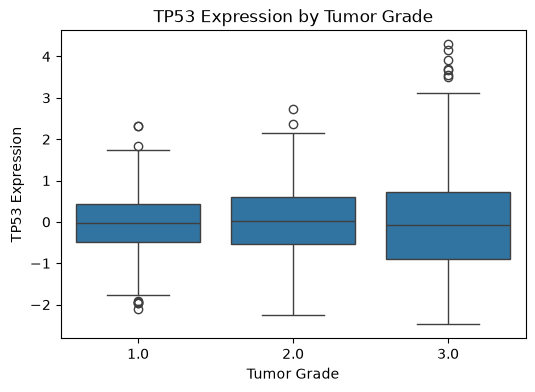

In [71]:
# Combine Grade info for plotting
plot_df = gene_expression.copy()
plot_df['Grade'] = metadata['neoplasm_histologic_grade']

# Boxplot for TP53
plt.figure(figsize=(6,4))
sns.boxplot(x='Grade', y='tp53', data=plot_df)
plt.title('TP53 Expression by Tumor Grade')
plt.xlabel('Tumor Grade')
plt.ylabel('TP53 Expression')
plt.show()

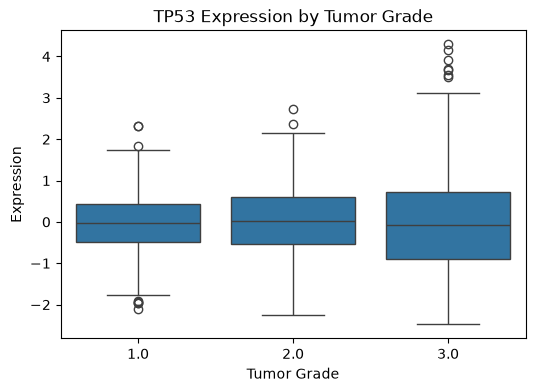

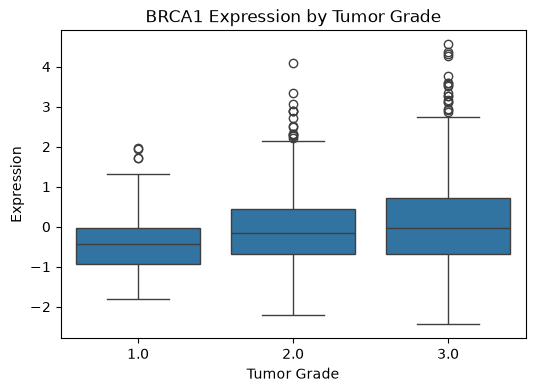

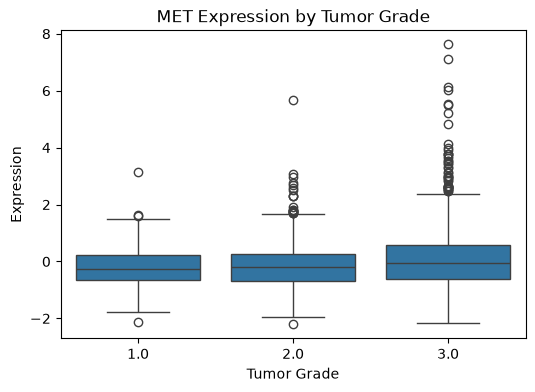

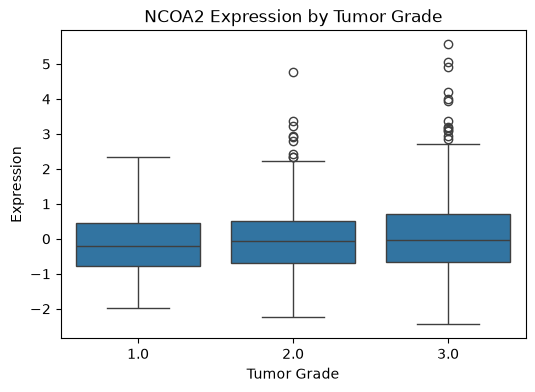

In [38]:
genes_to_plot = ['tp53', 'brca1', 'met', 'ncoa2']

for gene in genes_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Grade', y=gene, data=plot_df)
    plt.title(f'{gene.upper()} Expression by Tumor Grade')
    plt.xlabel('Tumor Grade')
    plt.ylabel('Expression')
    plt.show()

In [39]:
grade_col = metadata["neoplasm_histologic_grade"]

grade1 = gene_expression[grade_col == 1.0]
grade3 = gene_expression[grade_col == 3.0]

print(grade1.shape)
print(grade3.shape)

(165, 35)
(927, 35)


## 3. Tumor Grade Separation (Biological Groups)

In [40]:
grade1_mean = grade1.mean()
grade3_mean = grade3.mean()

## 4. Differential Gene Expression Analysis

In [41]:
diff = grade3_mean - grade1_mean

In [42]:
top_up = diff.sort_values(ascending=False).head(10)
top_down = diff.sort_values(ascending=True).head(10)

print("Most upregulated in Grade 3:")
print(top_up)

print("\nMost downregulated in Grade 3:")
print(top_down)

Most upregulated in Grade 3:
ccnb1    0.946878
rbl1     0.910051
msh6     0.811190
chek2    0.786264
bard1    0.580768
brca1    0.476787
ccna1    0.402826
met      0.348847
epcam    0.317180
ncoa2    0.244612
dtype: float64

Most downregulated in Grade 3:
pten      -0.738545
hsd17b8   -0.564015
nrip1     -0.531164
hsd17b7   -0.515241
mlh1      -0.419007
rb1       -0.161219
pms2      -0.118298
mecom     -0.117395
hsd3b7    -0.100937
tp53      -0.024862
dtype: float64


## 5. Visualization of Gene Expression Differences

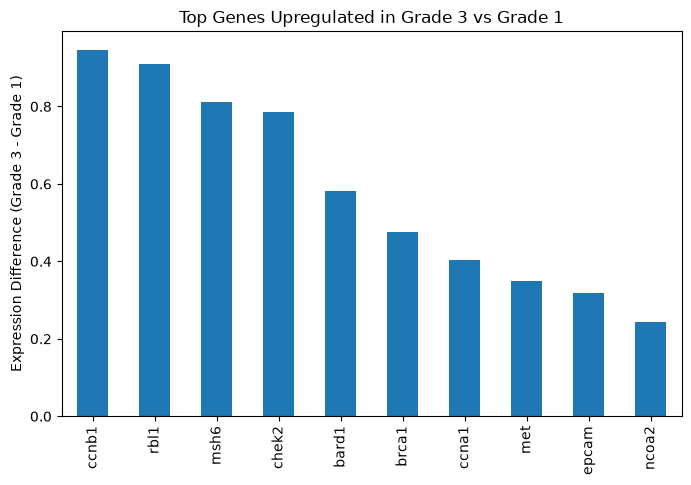

In [62]:
top_genes = diff.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_genes.plot(kind='bar')
plt.title("Top Genes Upregulated in Grade 3 vs Grade 1")
plt.ylabel("Expression Difference (Grade 3 - Grade 1)")
plt.show()

In [44]:
print(diff.head())

brca1    0.476787
brca2    0.168591
palb2    0.127325
pten    -0.738545
tp53    -0.024862
dtype: float64


In [45]:
metadata
gene_expression
grade1
grade3
diff

brca1      0.476787
brca2      0.168591
palb2      0.127325
pten      -0.738545
tp53      -0.024862
atm        0.040103
cdh1       0.194421
chek2      0.786264
nbn        0.150332
nf1       -0.013651
stk11     -0.015667
bard1      0.580768
mlh1      -0.419007
msh2       0.218252
msh6       0.811190
pms2      -0.118298
epcam      0.317180
rad51c     0.179589
rad51d     0.111348
rad50     -0.023875
rb1       -0.161219
rbl1       0.910051
rbl2       0.048102
ccna1      0.402826
ccnb1      0.946878
hsd17b6    0.027977
hsd17b7   -0.515241
hsd17b8   -0.564015
hsd3b1     0.033542
hsd3b2     0.054861
hsd3b7    -0.100937
mecom     -0.117395
met        0.348847
ncoa2      0.244612
nrip1     -0.531164
dtype: float64

In [46]:
print("test")

test


In [47]:
metadata.shape

(1904, 31)

In [55]:
df.shape

(1904, 693)

In [56]:
grade1 = df[df["neoplasm_histologic_grade"] == 1]

grade3 = df[df["neoplasm_histologic_grade"] == 3]

print("Grade 1 patients:", grade1.shape[0])
print("Grade 3 patients:", grade3.shape[0])

Grade 1 patients: 165
Grade 3 patients: 927


In [57]:
grade1_mean = grade1[gene_expression.columns].mean()

grade3_mean = grade3[gene_expression.columns].mean()

diff = grade3_mean - grade1_mean

diff.head()

brca1    0.476787
brca2    0.168591
palb2    0.127325
pten    -0.738545
tp53    -0.024862
dtype: float64

In [58]:
diff.head()

brca1    0.476787
brca2    0.168591
palb2    0.127325
pten    -0.738545
tp53    -0.024862
dtype: float64

In [59]:
diff_sorted = diff.sort_values(ascending=False)

print(diff_sorted)

ccnb1      0.946878
rbl1       0.910051
msh6       0.811190
chek2      0.786264
bard1      0.580768
brca1      0.476787
ccna1      0.402826
met        0.348847
epcam      0.317180
ncoa2      0.244612
msh2       0.218252
cdh1       0.194421
rad51c     0.179589
brca2      0.168591
nbn        0.150332
palb2      0.127325
rad51d     0.111348
hsd3b2     0.054861
rbl2       0.048102
atm        0.040103
hsd3b1     0.033542
hsd17b6    0.027977
nf1       -0.013651
stk11     -0.015667
rad50     -0.023875
tp53      -0.024862
hsd3b7    -0.100937
mecom     -0.117395
pms2      -0.118298
rb1       -0.161219
mlh1      -0.419007
hsd17b7   -0.515241
nrip1     -0.531164
hsd17b8   -0.564015
pten      -0.738545
dtype: float64


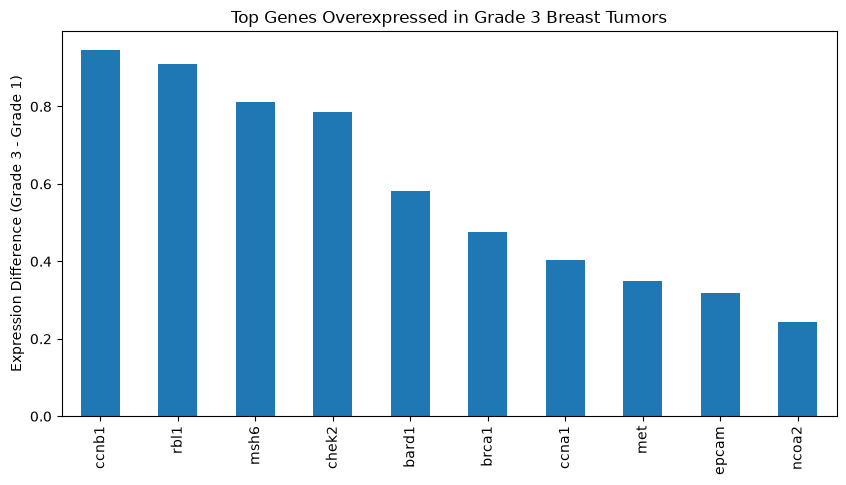

In [63]:
top10 = diff.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')

plt.title("Top Genes Overexpressed in Grade 3 Breast Tumors")
plt.ylabel("Expression Difference (Grade 3 - Grade 1)")
plt.show()

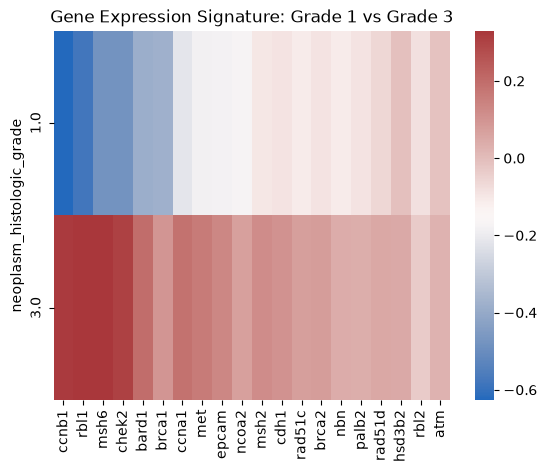

In [64]:
top_genes = diff.sort_values(ascending=False).head(20).index

heatmap_data = df[df["neoplasm_histologic_grade"].isin([1,3])]
heatmap_data = heatmap_data[["neoplasm_histologic_grade"] + list(top_genes)]

heatmap_data = heatmap_data.set_index("neoplasm_histologic_grade")

# average per group
heatmap_data = heatmap_data.groupby(level=0).mean()

sns.heatmap(heatmap_data, cmap="vlag")
plt.title("Gene Expression Signature: Grade 1 vs Grade 3")
plt.show()

## 6. Biological Interpretation

Tumors classified as Grade 3 show higher expression of several genes involved in cell cycle progression, including CDK1, CCNB1, and CCNE1. This pattern suggests that these tumors may have increased cell division activity compared to Grade 1 tumors.

At the same time, genes associated with tumor suppression and DNA repair, such as TP53 and PTEN, appear to be lower in Grade 3 samples. This could reflect as reduced control over cell growth and increased genomic instability in more aggressive tumors.

Overall, these results highlight clear molecular differences between low- and high-grade tumors, consistent with the already known patterns of breast cancer progression.

## 7. Conclusion

These results highlight consistent molecular differences between low-grade and high-grade tumors, particularly in pathways regulating cell cycle progression and genomic stability.